In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
df=pd.read_csv('creditcard.csv')

In [4]:
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.drop(columns='Time', inplace=True)

In [7]:
print("no. of null values are", df.isnull().sum().sum())

no. of null values are 0


In [8]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
def detect_outliers_iqr(dataframe):
    outlier_dict = {}
    for col in dataframe.columns:
            Q1 = dataframe[col].quantile(0.25)
            Q3 = dataframe[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)]
            
            outlier_dict[col] = len(outliers) 
    return outlier_dict

outliers_per_column = detect_outliers_iqr(df)


for col, count in outliers_per_column.items():
    print(f"Column {col} has {count} outliers")

Column V1 has 7062 outliers
Column V2 has 13526 outliers
Column V3 has 3363 outliers
Column V4 has 11148 outliers
Column V5 has 12295 outliers
Column V6 has 22965 outliers
Column V7 has 8948 outliers
Column V8 has 24134 outliers
Column V9 has 8283 outliers
Column V10 has 9496 outliers
Column V11 has 780 outliers
Column V12 has 15348 outliers
Column V13 has 3368 outliers
Column V14 has 14149 outliers
Column V15 has 2894 outliers
Column V16 has 8184 outliers
Column V17 has 7420 outliers
Column V18 has 7533 outliers
Column V19 has 10205 outliers
Column V20 has 27770 outliers
Column V21 has 14497 outliers
Column V22 has 1317 outliers
Column V23 has 18541 outliers
Column V24 has 4774 outliers
Column V25 has 5367 outliers
Column V26 has 5596 outliers
Column V27 has 39163 outliers
Column V28 has 30342 outliers
Column Amount has 31904 outliers
Column Class has 492 outliers


C:\Users\admin\AppData\Local\Temp\ipykernel_14024\872686819.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Class'], y=df[col], palette=['blue', 'red'])
C:\Users\admin\AppData\Local\Temp\ipykernel_14024\872686819.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Class'], y=df[col], palette=['blue', 'red'])
C:\Users\admin\AppData\Local\Temp\ipykernel_14024\872686819.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Class'], y=df[col], palette=['blue', 'red'])
C:\Users\admin\AppData\Local\Temp\ipykernel_14024\87268681

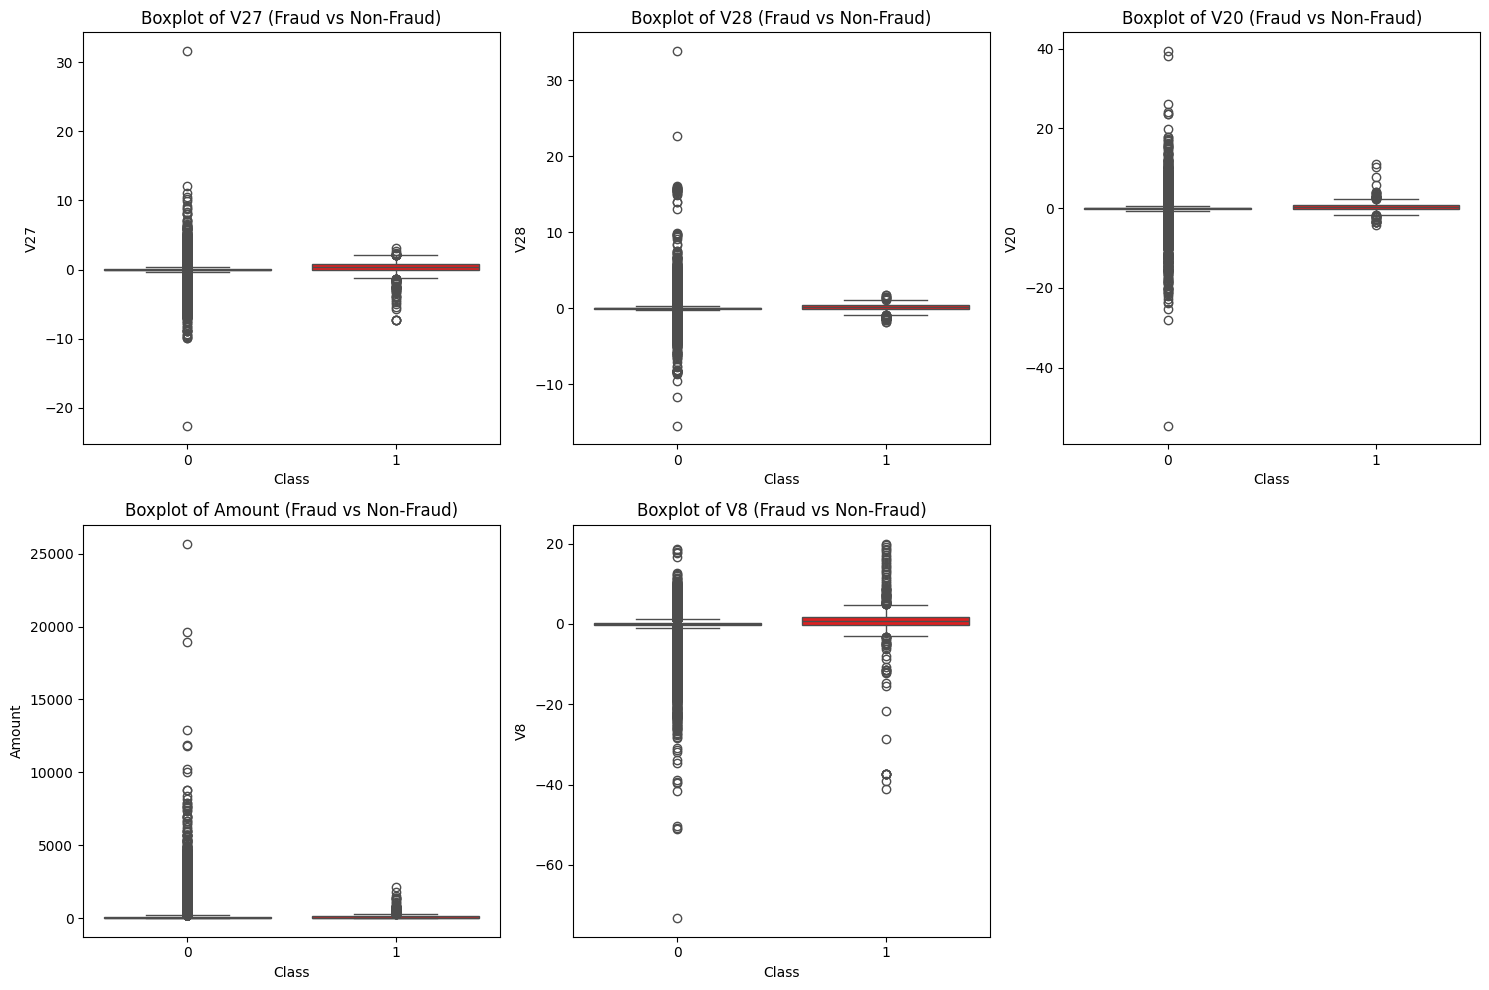

In [10]:
fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]
outlier_cols = ['V27', 'V28', 'V20', 'Amount', 'V8'] 
plt.figure(figsize=(15, 10))
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df['Class'], y=df[col], palette=['blue', 'red'])
    plt.title(f"Boxplot of {col} (Fraud vs Non-Fraud)")

plt.tight_layout()
plt.show()

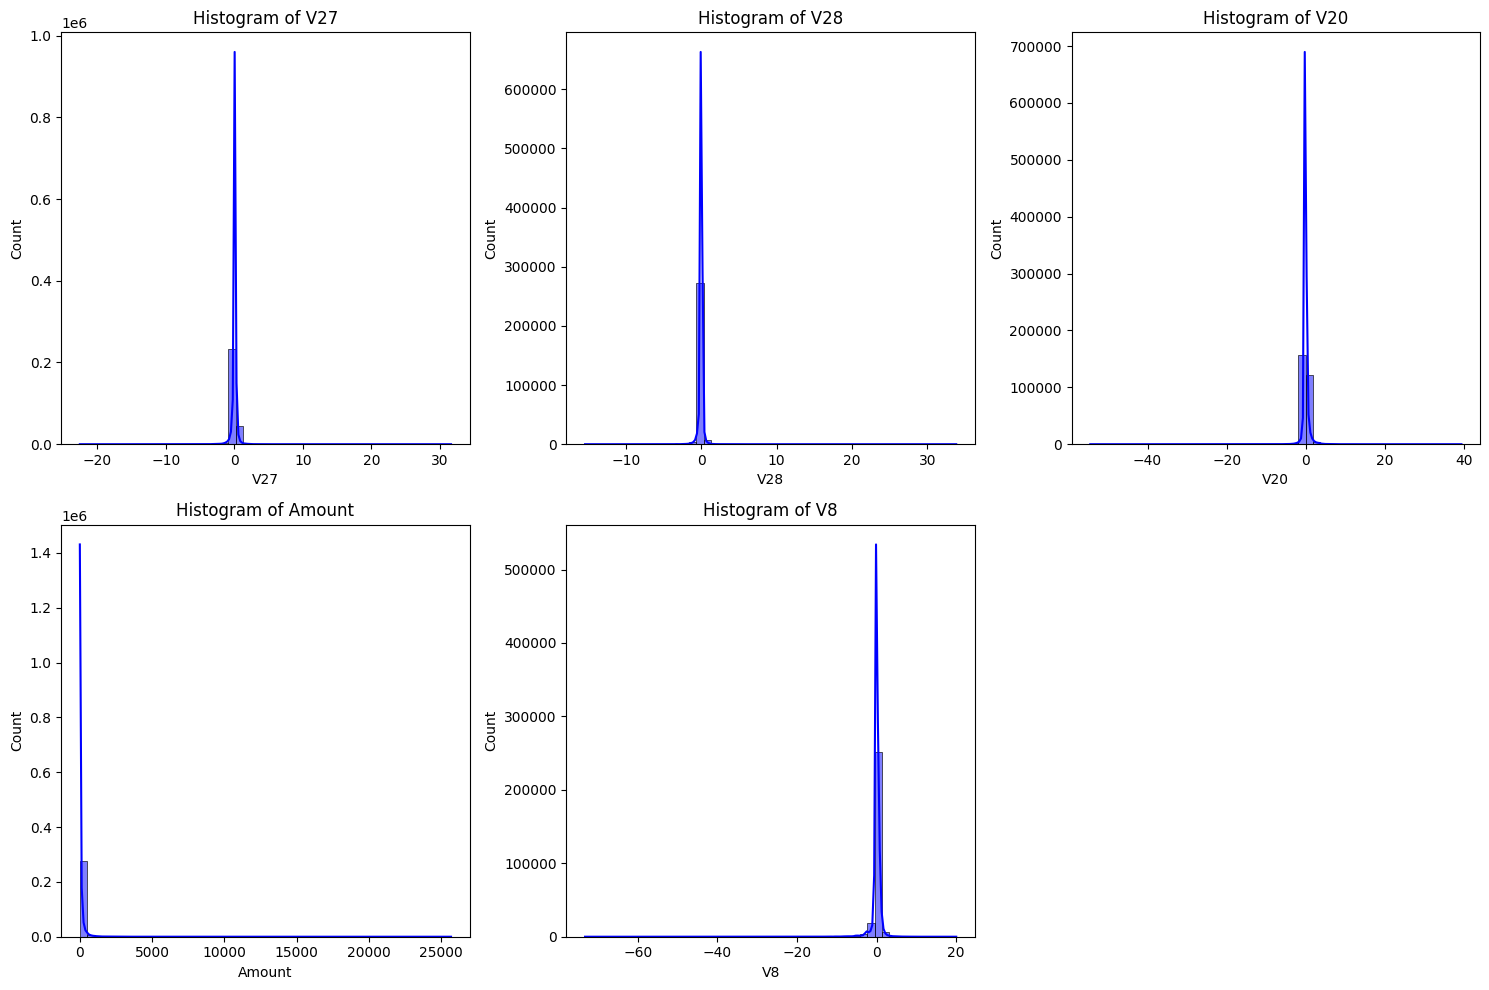

In [11]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=50, kde=True, color="blue")
    plt.title(f"Histogram of {col}")

plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_14024\323262688.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Class'], palette=['blue', 'red'])


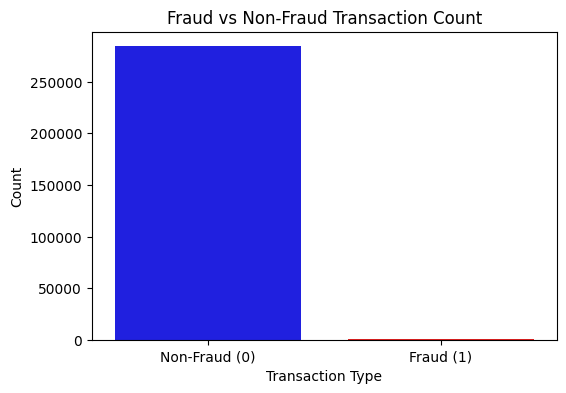

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Class'], palette=['blue', 'red'])
plt.title("Fraud vs Non-Fraud Transaction Count")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

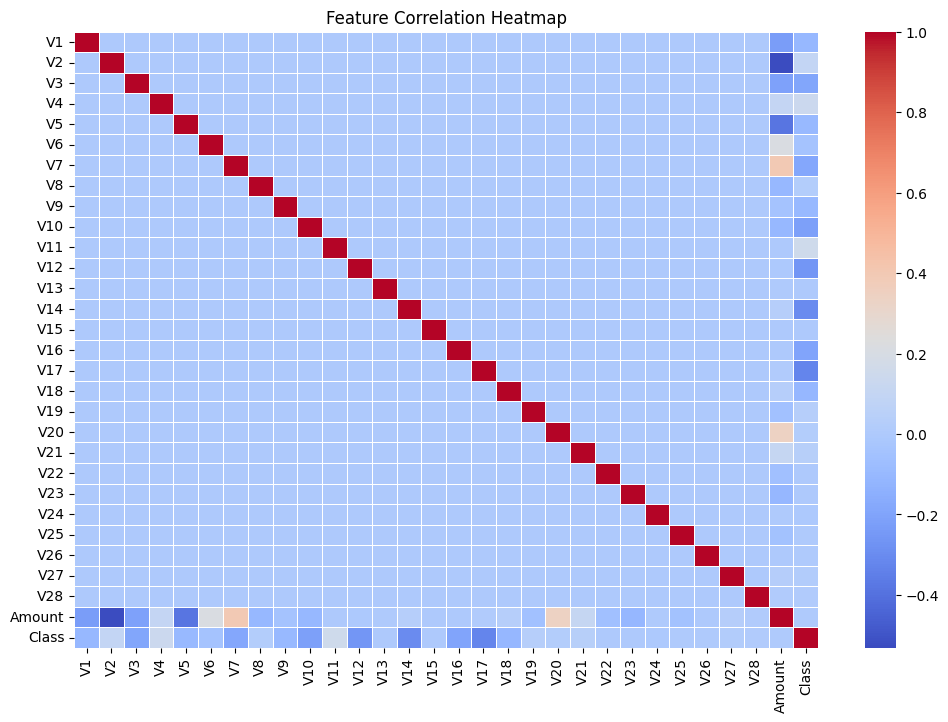

In [13]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

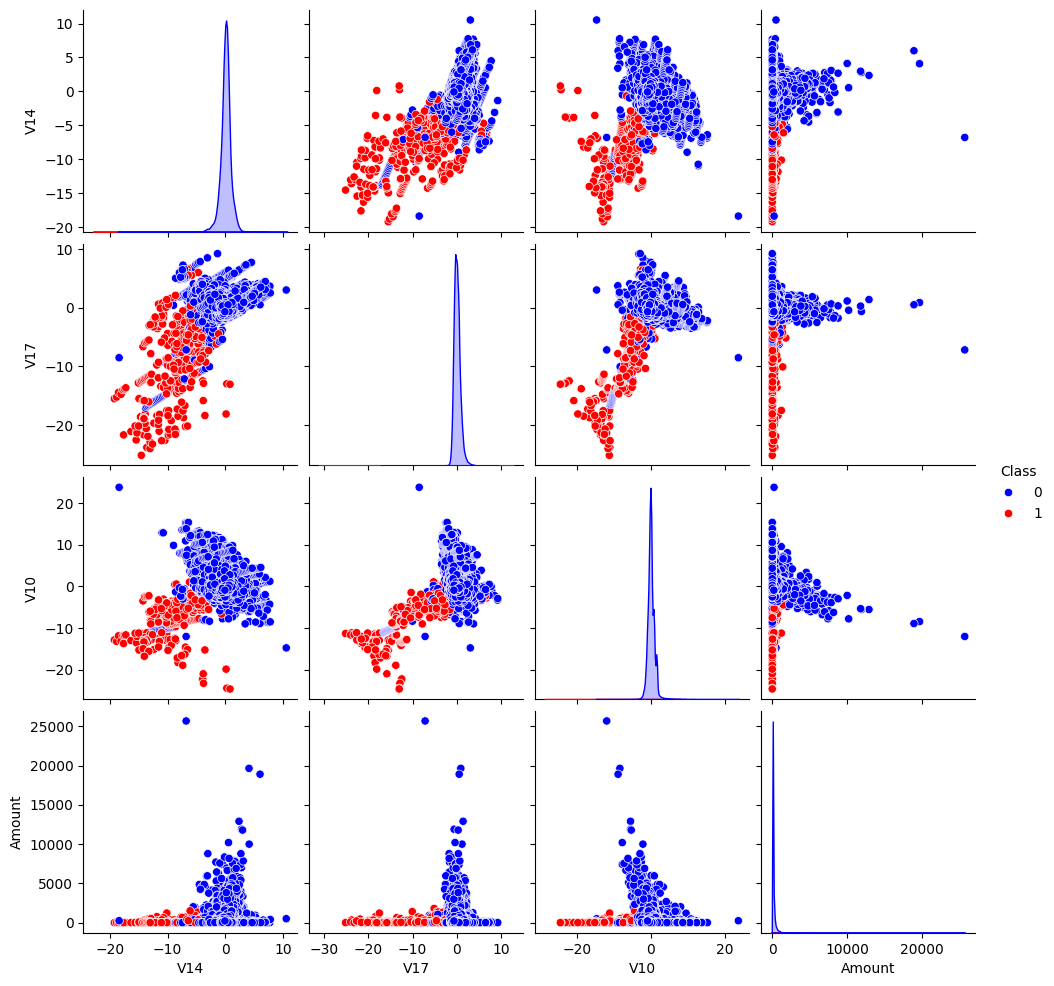

In [14]:
selected_features = ['V14', 'V17', 'V10', 'Amount', 'Class']
sns.pairplot(df[selected_features], hue='Class', palette=['blue', 'red'])
plt.show()

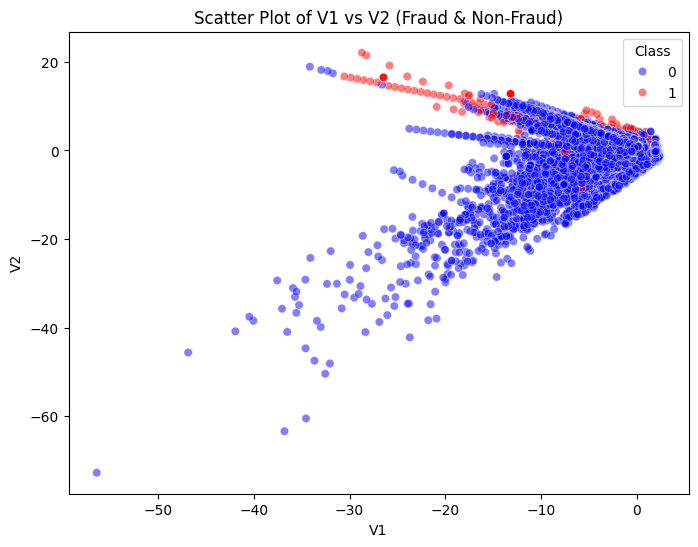

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['V1'], y=df['V2'], hue=df['Class'], palette=['blue', 'red'], alpha=0.5)
plt.title("Scatter Plot of V1 vs V2 (Fraud & Non-Fraud)")
plt.show()

In [34]:
X = df.drop(columns=['Class'])  
y = df['Class']

In [36]:
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

In [38]:
X.iloc[:, 1:29] = scaler_standard.fit_transform(X.iloc[:, 1:29])

In [40]:
X['Amount'] = scaler_minmax.fit_transform(X[['Amount']])

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [44]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [46]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"📊 {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

📊 Logistic Regression Accuracy: 0.9992
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962

📊 Random Forest Accuracy: 0.9996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

📊 Gradient Boosting Accuracy: 0.9983
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.53      0.18      0.27        98

    accuracy                           1.00     56962
   macro avg       

In [48]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Output Layer
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,505 (5.88 KB)

 Trainable params: 1,505 (5.88 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))
y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
nn_acc = accuracy_score(y_test, y_pred_nn)
print(f"Neural Network Accuracy: {nn_acc:.4f}")
print(classification_report(y_test, y_pred_nn))

Epoch 1/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9890 - loss: 0.0410 - val_accuracy: 0.9993 - val_loss: 0.0036
Epoch 2/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9992 - loss: 0.0044 - val_accuracy: 0.9994 - val_loss: 0.0036
Epoch 3/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9993 - loss: 0.0041 - val_accuracy: 0.9993 - val_loss: 0.0034
Epoch 4/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9992 - val_loss: 0.0033
Epoch 5/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9992 - val_loss: 0.0033
Epoch 6/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9993 - loss: 0.0037 - val_accuracy: 0.9993 - val_loss: 0.0032
Epoch 7/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - accuracy: 0.9993 - loss: 0.0033 - val_accuracy: 0.9993 - val_loss: 0.0034
Epoch 8/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9994 - loss: 0.0029

In [54]:
import joblib
best_model = models["Random Forest"]
joblib.dump(best_model, "best_model_rf.pkl")
print("Best model saved as 'best_model_rf1.pkl'")

Best model saved as 'best_model_rf1.pkl'
